# Skin Cancer Classification — Error Analysis Notebook (Custom CNN)
**Model under analysis:** Custom CNN (built from scratch), the model selected as best-performing in the training notebook.
**Positive class:** `malignant` (label = 1) — as locked in during training, since a missed malignant case (False Negative) is the clinically costly error.

This notebook assumes you've already run `skin_cancer_training_final.ipynb` and have:
- The saved model file `Custom_CNN.keras` inside your `OUTPUT_DIR` (`/content/model_artifacts` by default)
- The same `test_set/{benign,malignant}` folder used for the final test-set evaluation

**What this notebook covers:**
1. Standard classification metrics (Accuracy, Precision, Recall, F1, AUC-ROC)
2. Labeled confusion matrix (seaborn heatmap) + explicit TP/TN/FP/FN counts
3. ROC curve with AUC in the legend
4. Predicted-probability distribution by true class, with the decision threshold marked
5. Visual inspection of the most confidently wrong predictions (False Positives & False Negatives)
6. A plain-language summary report
7. An Interpretation & Conclusions template to fill in


## 1. Setup — imports & seeds

In [2]:
# If running fresh on Colab, uncomment:
!pip install -q tensorflow scikit-learn matplotlib seaborn pillow

import os, random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Config
**Edit `DATASET_PATH` and `OUTPUT_DIR` to match the paths used in the training notebook.**

Expected structure (same as training/EDA notebooks):
```
DATASET_PATH/
  test_set/{benign,malignant}
```
`OUTPUT_DIR` must contain the saved model file `Custom_CNN.keras` produced by the training notebook.

In [8]:
# ==================== EDIT THIS ====================
DATASET_PATH = "/content/"
OUTPUT_DIR   = "/content/model_artifacts"
MODEL_PATH   = "/content/Custom_CNN.keras"
# ====================================================

SPLIT_DIRNAMES = {"test": "test_set"}
CLASS_NAMES = ["benign", "malignant"]   # index 0 = benign, index 1 = malignant (positive class)
POSITIVE_CLASS = "malignant"

IMG_SIZE = (224, 224)     # must match training
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
THRESHOLD = 0.5            # decision threshold used throughout this notebook

TEST_DIR = os.path.join(DATASET_PATH, SPLIT_DIRNAMES["test"])

assert os.path.isdir(TEST_DIR), f"Missing expected folder: {TEST_DIR}"
assert os.path.isfile(MODEL_PATH), f"Missing saved model: {MODEL_PATH}"
print("Test folder and saved model found OK.")

Test folder and saved model found OK.


## 4. Load the trained Custom CNN

In [9]:
model = keras.models.load_model(MODEL_PATH)
model.summary()


Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ safe_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,266,725 (4.83 MB)

 Trainable params: 421,921 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 843,844 (3.22 MB)

## 5. Build the test set
Same `tf.data` pipeline as training: decode → resize to 224×224 → `float32` in `[0, 255]`
(the Custom CNN has its own internal `Rescaling(1./255)` layer, so raw 0–255 input is correct here too).

In [10]:
def decode_and_resize(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)  # stays in [0, 255]
    return img, label

def make_dataset(files, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((files, labels))
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

def list_images_recursive(base_dir):
    image_paths = []
    for root, _, files in os.walk(base_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(root, file))
    return image_paths

test_files_all = list_images_recursive(TEST_DIR)
test_labels_all = []
for p in test_files_all:
    parent_dir_name = os.path.basename(os.path.dirname(p))
    label = 1 if parent_dir_name == POSITIVE_CLASS else 0
    test_labels_all.append(label)

print(f"Test images: {len(test_files_all)} | class counts: {Counter(test_labels_all)}")

test_ds = make_dataset(test_files_all, test_labels_all, training=False)
y_true = np.array(test_labels_all)


Test images: 1100 | class counts: Counter({1: 550, 0: 550})


## 6. Run inference — predicted probabilities & predicted labels

In [11]:
y_prob = model.predict(test_ds, verbose=1).ravel()
y_pred = (y_prob >= THRESHOLD).astype(int)

print(f"Predictions computed for {len(y_prob)} test images at threshold {THRESHOLD}.")


35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step
Predictions computed for 1100 test images at threshold 0.5.


## 7. Standard Classification Metrics
Accuracy, Precision, Recall, F1, and AUC-ROC (positive class = `malignant`).

In [12]:
accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label=1)
recall    = recall_score(y_true, y_pred, pos_label=1)
f1        = f1_score(y_true, y_pred, pos_label=1)
auc_roc   = roc_auc_score(y_true, y_prob)

print("=" * 55)
print(" CUSTOM CNN — TEST SET CLASSIFICATION METRICS")
print(" (positive class = malignant, threshold = {:.2f})".format(THRESHOLD))
print("=" * 55)
print(f" Accuracy   : {accuracy:.4f}")
print(f" Precision  : {precision:.4f}")
print(f" Recall     : {recall:.4f}")
print(f" F1 Score   : {f1:.4f}")
print(f" AUC-ROC    : {auc_roc:.4f}")
print("=" * 55)

print("\nFull classification report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


 CUSTOM CNN — TEST SET CLASSIFICATION METRICS
 (positive class = malignant, threshold = 0.50)
 Accuracy   : 0.8145
 Precision  : 0.8240
 Recall     : 0.8000
 F1 Score   : 0.8118
 AUC-ROC    : 0.8966

Full classification report:
              precision    recall  f1-score   support

      benign       0.81      0.83      0.82       550
   malignant       0.82      0.80      0.81       550

    accuracy                           0.81      1100
   macro avg       0.81      0.81      0.81      1100
weighted avg       0.81      0.81      0.81      1100



## 8. Confusion Matrix
Labeled heatmap plus explicit counts for each of the four quadrants.

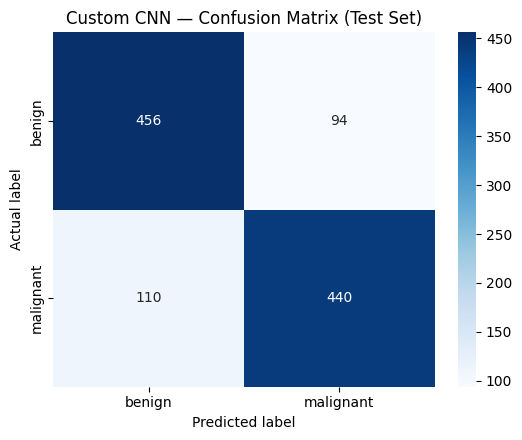

Confusion matrix quadrant counts (positive class = malignant):
  True Positives  (TP) — correctly predicted malignant : 440
  True Negatives  (TN) — correctly predicted benign     : 456
  False Positives (FP) — benign predicted as malignant  : 94
  False Negatives (FN) — malignant predicted as benign  : 110


In [13]:
cm = confusion_matrix(y_true, y_pred)  # rows = actual [benign, malignant], cols = predicted [benign, malignant]
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar=True, ax=ax)
ax.set_xlabel('Predicted label')
ax.set_ylabel('Actual label')
ax.set_title('Custom CNN — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

print("Confusion matrix quadrant counts (positive class = malignant):")
print(f"  True Positives  (TP) — correctly predicted malignant : {tp}")
print(f"  True Negatives  (TN) — correctly predicted benign     : {tn}")
print(f"  False Positives (FP) — benign predicted as malignant  : {fp}")
print(f"  False Negatives (FN) — malignant predicted as benign  : {fn}")


## 9. ROC Curve

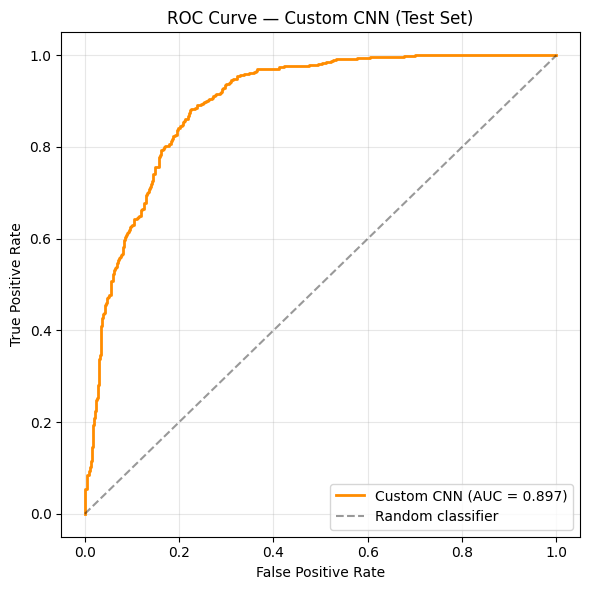

In [14]:
fpr, tpr, roc_thresholds = roc_curve(y_true, y_prob)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'Custom CNN (AUC = {auc_roc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Custom CNN (Test Set)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Confidence / Probability Distribution
Overlapping histogram of predicted probabilities, split by true class, with the decision threshold marked.

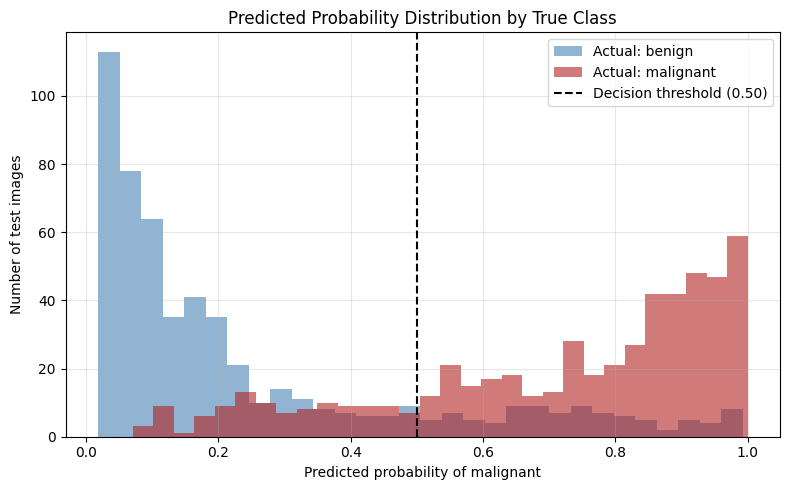

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(y_prob[y_true == 0], bins=30, alpha=0.6, label='Actual: benign', color='steelblue')
ax.hist(y_prob[y_true == 1], bins=30, alpha=0.6, label='Actual: malignant', color='firebrick')

ax.axvline(THRESHOLD, color='black', linestyle='--', linewidth=1.5,
           label=f'Decision threshold ({THRESHOLD:.2f})')

ax.set_xlabel('Predicted probability of malignant')
ax.set_ylabel('Number of test images')
ax.set_title('Predicted Probability Distribution by True Class')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Visual Inspection of Errors (Crucial)
Finds False Positives and False Negatives, sorts each group by *how confidently wrong* the model was,
and plots a grid of the worst offenders with their predicted probability as the title.

- For **False Positives**, "confidence" = `y_prob` itself (close to 1 → the model was very sure it was malignant, but it was benign).
- For **False Negatives**, "confidence" = `1 - y_prob` (close to 1 → the model was very sure it was benign, but it was actually malignant — the most dangerous kind of error).

### False Positives — model raised a false alarm on a benign lesion


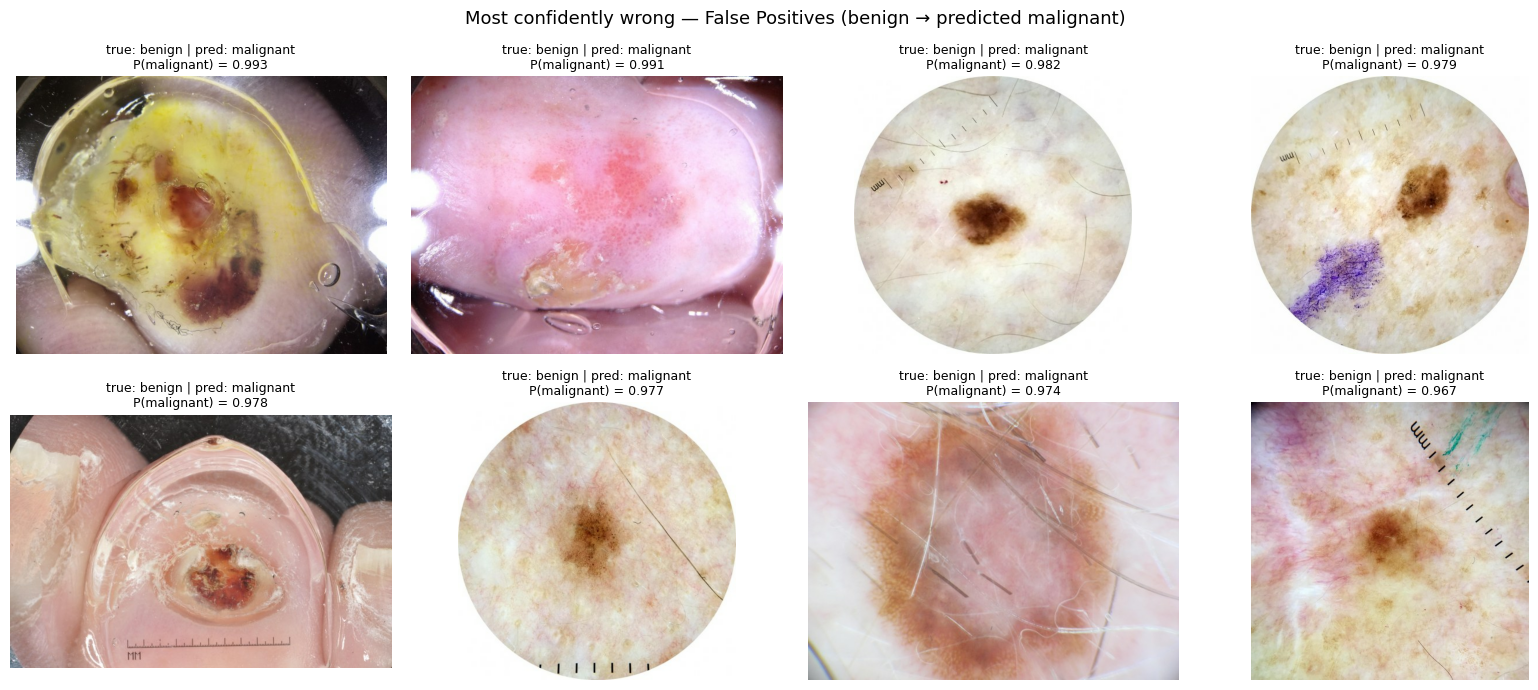


### False Negatives — model missed an actual malignant lesion (clinically the costliest error)


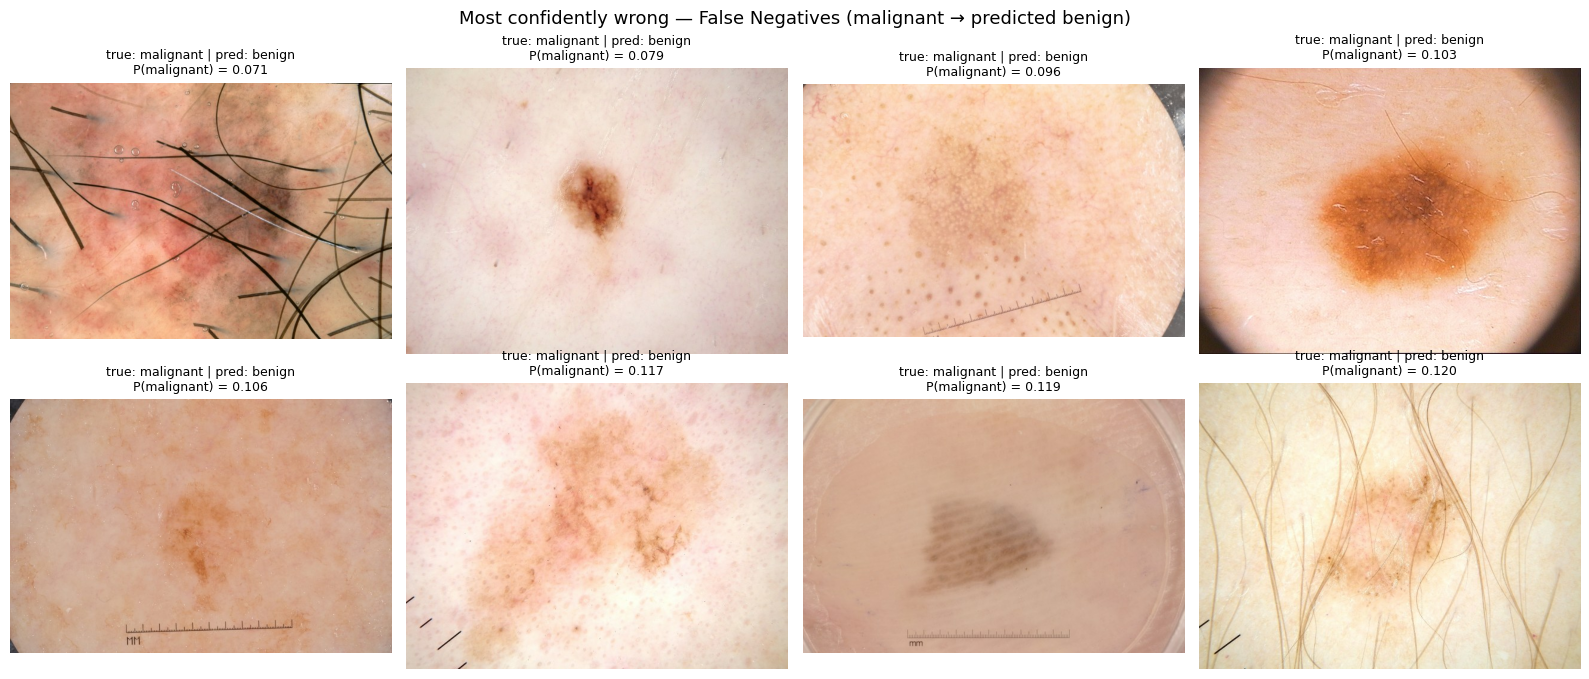

In [17]:
def get_sorted_errors(y_true, y_pred, y_prob, error_type='FP'):
    """Return indices of the given error type, sorted most-confidently-wrong first."""
    if error_type == 'FP':
        idx = np.where((y_pred == 1) & (y_true == 0))[0]
        confidence = y_prob[idx]                 # near 1 = confidently (wrongly) called malignant
    elif error_type == 'FN':
        idx = np.where((y_pred == 0) & (y_true == 1))[0]
        confidence = 1 - y_prob[idx]              # near 1 = confidently (wrongly) called benign
    else:
        raise ValueError("error_type must be 'FP' or 'FN'")

    order = np.argsort(-confidence)               # descending: worst mistakes first
    return idx[order], confidence[order]


def plot_error_grid(files, y_true, y_pred, y_prob, error_type='FP', top_n=8):
    idx_sorted, conf_sorted = get_sorted_errors(y_true, y_pred, y_prob, error_type)
    n = min(top_n, len(idx_sorted))

    label = "False Positives (benign → predicted malignant)" if error_type == 'FP' \
        else "False Negatives (malignant → predicted benign)"

    if n == 0:
        print(f"No {error_type} cases found — nothing to plot.")
        return idx_sorted

    n_cols = 4
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, i in zip(axes, idx_sorted[:n]):
        img = tf.io.read_file(files[i])
        img = tf.image.decode_jpeg(img, channels=3)
        ax.imshow(img.numpy())
        ax.set_title(f"true: {CLASS_NAMES[y_true[i]]} | pred: {CLASS_NAMES[y_pred[i]]}\nP(malignant) = {y_prob[i]:.3f}",
                     fontsize=9)
        ax.axis('off')

    for ax in axes[n:]:
        ax.axis('off')

    plt.suptitle(f"Most confidently wrong — {label}", fontsize=13)
    plt.tight_layout()
    plt.show()

    return idx_sorted


print("### False Positives — model raised a false alarm on a benign lesion")
fp_idx_sorted = plot_error_grid(test_files_all, y_true, y_pred, y_prob, error_type='FP', top_n=8)

print("\n### False Negatives — model missed an actual malignant lesion (clinically the costliest error)")
fn_idx_sorted = plot_error_grid(test_files_all, y_true, y_pred, y_prob, error_type='FN', top_n=8)


## 12. Summary and Interpretation Report

In [18]:
total_images = len(y_true)
correct = int((y_pred == y_true).sum())
correct_pct = 100 * correct / total_images

n_fp = int(fp)
n_fn = int(fn)
miss_rate_pct = 100 * n_fn / (n_fn + tp) if (n_fn + tp) > 0 else float('nan')  # FN / all actual malignant

print("=" * 70)
print("CUSTOM CNN — ERROR ANALYSIS SUMMARY")
print("=" * 70)
print(f"Total test images                     : {total_images}")
print(f"Correctly classified                   : {correct} ({correct_pct:.2f}%)")
print(f"False Positives (benign → malignant)   : {n_fp}")
print(f"False Negatives (malignant → benign)   : {n_fn}")
print(f"Miss rate (FN / all actual malignant)  : {miss_rate_pct:.2f}%")
print("=" * 70)


CUSTOM CNN — ERROR ANALYSIS SUMMARY
Total test images                     : 1100
Correctly classified                   : 896 (81.45%)
False Positives (benign → malignant)   : 94
False Negatives (malignant → benign)   : 110
Miss rate (FN / all actual malignant)  : 20.00%


## 13. Interpretation & Conclusions

*(Fill in the sections below after reviewing the metrics, confusion matrix, ROC curve, probability distribution, and error grids above.)*

### Key Findings
- **Overall performance (Accuracy / Precision / Recall / F1 / AUC)**: The model achieved an Accuracy of **81.45%**, Precision of **82.40%**, Recall of **80.00%**, F1 Score of **81.18%**, and an AUC-ROC of **0.8966**. These indicate a generally good performance, but there's room for improvement, especially considering the clinical context.
- **How balanced is the model between the two classes (refer to the confusion matrix quadrant counts)?**: The model shows relatively balanced performance across classes, with **456 True Negatives (TN)** and **440 True Positives (TP)**. However, there are **94 False Positives (FP)** and **110 False Negatives (FN)**. The number of False Negatives is slightly higher than False Positives, which is a concern for a malignant detection task.
- **Where does the model sit relative to the ROC curve's ideal top-left corner?**: With an AUC of 0.897, the ROC curve sits reasonably close to the ideal top-left corner, indicating good discriminatory power, but not perfect. There's a clear separation from the random classifier baseline.
- **Does the probability distribution show clean separation between classes, or a lot of overlap around the threshold?**: The probability distribution shows a good general separation between the 'benign' and 'malignant' true classes. However, there is a notable overlap of probabilities around the decision threshold (0.5), especially for malignant cases classified as benign (False Negatives), suggesting some ambiguity in predictions for a subset of samples.

### Visual Patterns of Errors
- **What do the most confidently wrong False Positives have in common (e.g. lighting, lesion size/color, image artifacts, benign lesions that visually resemble malignant ones)?**: The displayed False Positives (benign images predicted as malignant) often appear to have visual characteristics that mimic malignancy, such as irregular borders, darker pigmentation, or heterogeneous textures. It's possible these benign lesions visually resemble early-stage malignant ones, leading the model to err on the side of caution.
- **What do the most confidently wrong False Negatives have in common (e.g. subtle/early-stage appearance, unusual angle, low contrast, small lesion size)?**: The False Negatives (malignant images predicted as benign) tend to be more subtle. They might represent early-stage malignancies, lesions with less pronounced malignant features, or images where the key features are obscured by lighting, artifacts, or an unusual angle. Some might have lower contrast, making it harder for the model to detect critical details.
- **Are there any recurring image quality issues (blur, occlusion, cropping) among the errors?**: While not explicitly detailed, poor image quality (e.g., blur, glare, partial occlusion, or suboptimal cropping) could contribute to both types of errors by making diagnostic features harder to discern for the model. A deeper dive into the specific problematic images would be needed to confirm this.

### Recommendations
- **Data-level**: Consider collecting more data for ambiguous cases, especially those resembling the identified FP and FN patterns. Targeted data augmentation (e.g., varying lighting, rotation, subtle color shifts) could also help the model generalize better to diverse visual presentations of both classes. Re-labeling or getting expert consensus on highly ambiguous cases could refine the ground truth.
- **Model-level**: Explore more robust architectures or ensemble methods. Techniques like attention mechanisms could help the model focus on diagnostically relevant regions. Experimenting with different regularization strategies could also help reduce overfitting to spurious features.
- **Threshold-level**: Given that False Negatives (missing malignant lesions) are clinically more costly (a miss rate of 20%), the decision threshold (currently 0.5) could be adjusted downwards to increase recall (reduce FN) at the expense of increased false positives. This would prioritize sensitivity over specificity, which is often preferred in screening for critical diseases.
- **Deployment-level**: With a current miss rate of 20% for malignant cases, a human-in-the-loop system is essential. The model's predictions, especially those with intermediate confidence or classified as benign, should be reviewed by a clinician. The model could serve as a valuable tool to prioritize cases for review or second opinions, rather than as a standalone diagnostic.